Using device: cuda
Stage 1 Training: VAE (SC + ST, Marker Genes)
Configuration:
   Marker genes per type: 100
   Batch size: 256
   Epochs: 500
   Learning rate: 0.001
   Beta (KL weight): 1.0
   Hidden dims: [512, 256]
   Latent dim: 128
Loading datasets...
   Found samples: ['CID4290', 'CID4465', 'CID44971', 'CID4535']
   Loading CID4290...
   SC: (5082, 27719)
   ST: (2427, 23116)
   Loading CID4465...
   SC: (1561, 27719)
   ST: (1203, 23157)
   Loading CID44971...
   SC: (1561, 27719)
   ST: (1203, 23157)
   Loading CID44971...
   SC: (7740, 27719)
   ST: (1147, 23531)
   Loading CID4535...
   SC: (3641, 27719)
   ST: (1122, 22331)
   Merging 4 SC samples...
   SC: (7740, 27719)
   ST: (1147, 23531)
   Loading CID4535...
   SC: (3641, 27719)
   ST: (1122, 22331)
   Merging 4 SC samples...
   Merging 4 ST samples...
   Merging 4 ST samples...
   SC total: (18024, 27719)
   ST total: (5899, 19632)
Computing clusters and marker genes...
Starting clustering analysis...
   SC total: (1

VAE Training:  74%|███████▍  | 369/500 [04:36<01:38,  1.33epoch/s, Train=79354.9773, Recon=78759.0817, KL=595.8954, Test=47109.4963]  



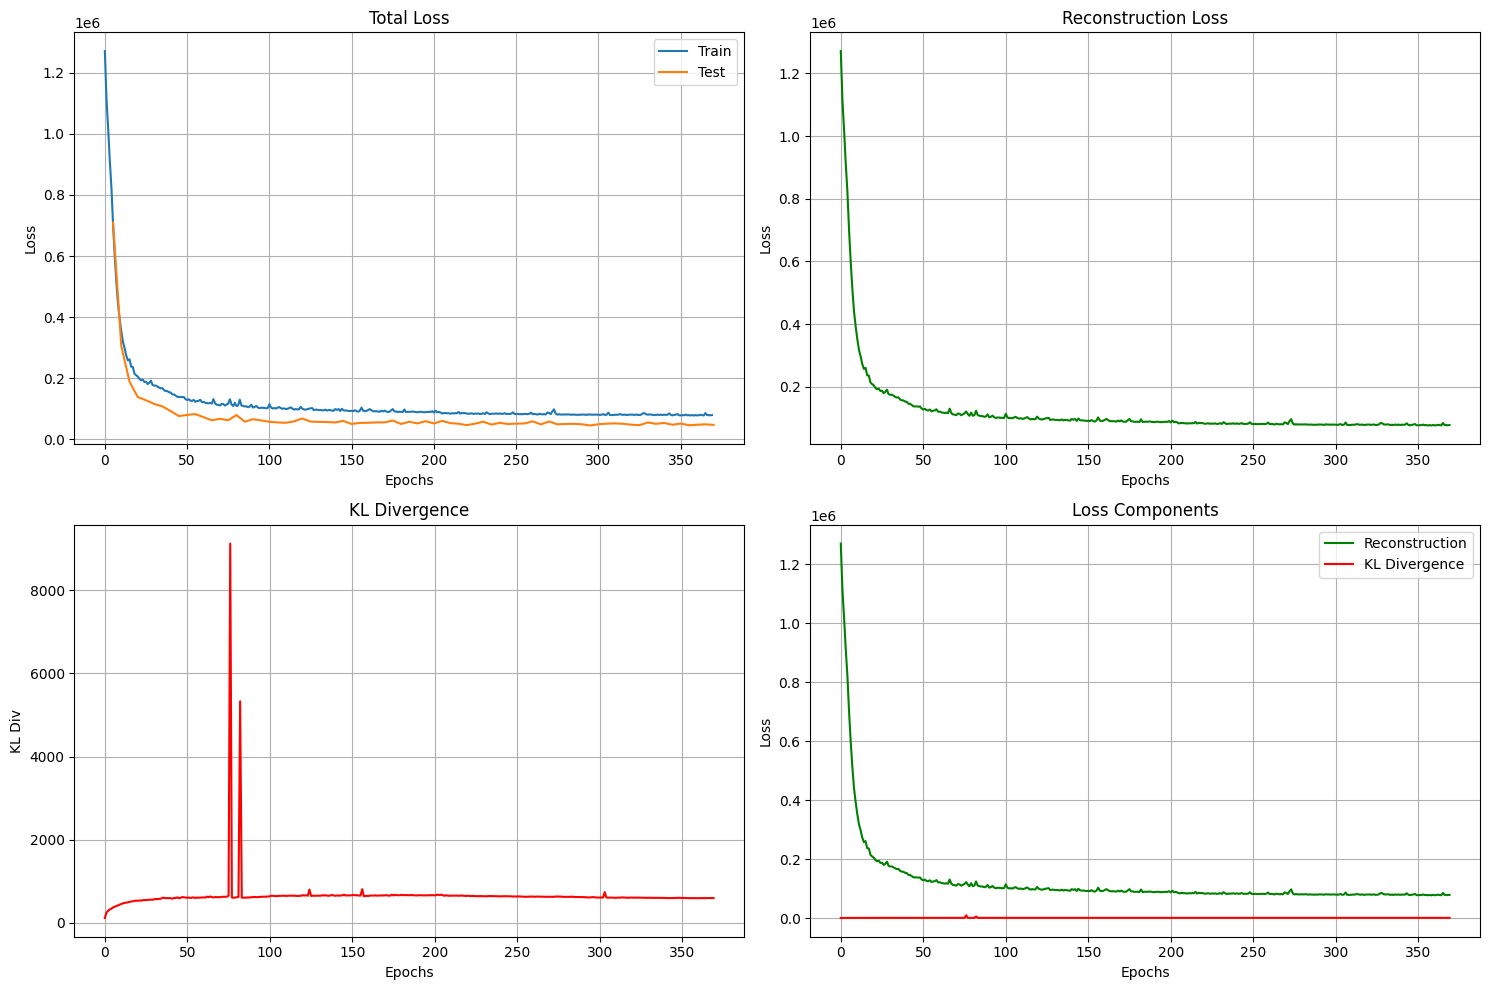

Computing cluster centers...
   SC training data: (16221, 1384)
   Number of clusters: 29
   Computing full gene cluster expressions...
      Total genes: 27719
   Completed: 29 clusters with center and expressions (all genes)
   Completed: 29 clusters with center and expressions (all genes)
Saving model to: ./stage1_results/2025_1024_1618/final_vae.pth
   Cluster centers: 29 clusters
   Cluster expressions (marker genes, count): 29 clusters
   Cluster expressions (all genes, count): 29 clusters
   Cluster expressions (all genes, count backup): 29 clusters
Saving model to: ./stage1_results/2025_1024_1618/final_vae.pth
   Cluster centers: 29 clusters
   Cluster expressions (marker genes, count): 29 clusters
   Cluster expressions (all genes, count): 29 clusters
   Cluster expressions (all genes, count backup): 29 clusters


In [1]:
%run stage1.py \
    --n_epochs 500 \
    --resolution 0.6 \
    --output_dir ./stage1_results/2025_1024_1618

Sample name: CID4465
Stage 1 model: ./stage1_results/final_vae.pth
Output directory: ./stage2_results/CID4465/2025_1024_1618
Device: cuda
Loading pretrained VAE Encoder...
Loaded cluster centers: torch.Size([36, 128])
Loaded cluster expressions: torch.Size([36, 1496])
Loaded full gene expressions (count): 36 clusters × 27719 genes
Loaded all genes list: 27719 genes
VAE Encoder loaded: 1496 -> 128
Cell type clusters: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '4', '5', '6', '7', '8', '9']
Marker genes: 1496
Using Stage 1 cluster centers and expressions...
Loaded 36 clusters
Using Stage 1 pretrained cluster data
   Cluster centers: torch.Size([36, 128])
   Cluster expressions: torch.Size([36, 1496])
Loading and processing spatial transcriptomics data...
Loading ST data: /home/maweicheng/ST_Graduation_Project/database/Wu/CID4465/CID4465_ST.h5ad


ST matching genes: 1496/1496
ST data: (1203, 1496)
Building GAT deconvolution model (clusters: 36)...
Building GAT model...
Hidden dim: 256
Layers: 6
Attention heads: 4
Dropout: 0.1
Loss: λ_pearson=1.0, λ_cosine=1.0, λ_align=1.0, λ_reg=0.5, λ_sparse=0.01
Parameters: 571,649
Starting GAT deconvolution training...
Starting GAT deconvolution training...
Cells per spot: 10.0
Parameters: 571,649
Starting GAT deconvolution training...
Starting GAT deconvolution training...
Cells per spot: 10.0


GAT Training:  28%|██▊       | 138/500 [04:36<12:04,  2.00s/epoch, Total=0.9038, Pearson=0.4772, Cosine=0.4242, Align=0.0019]



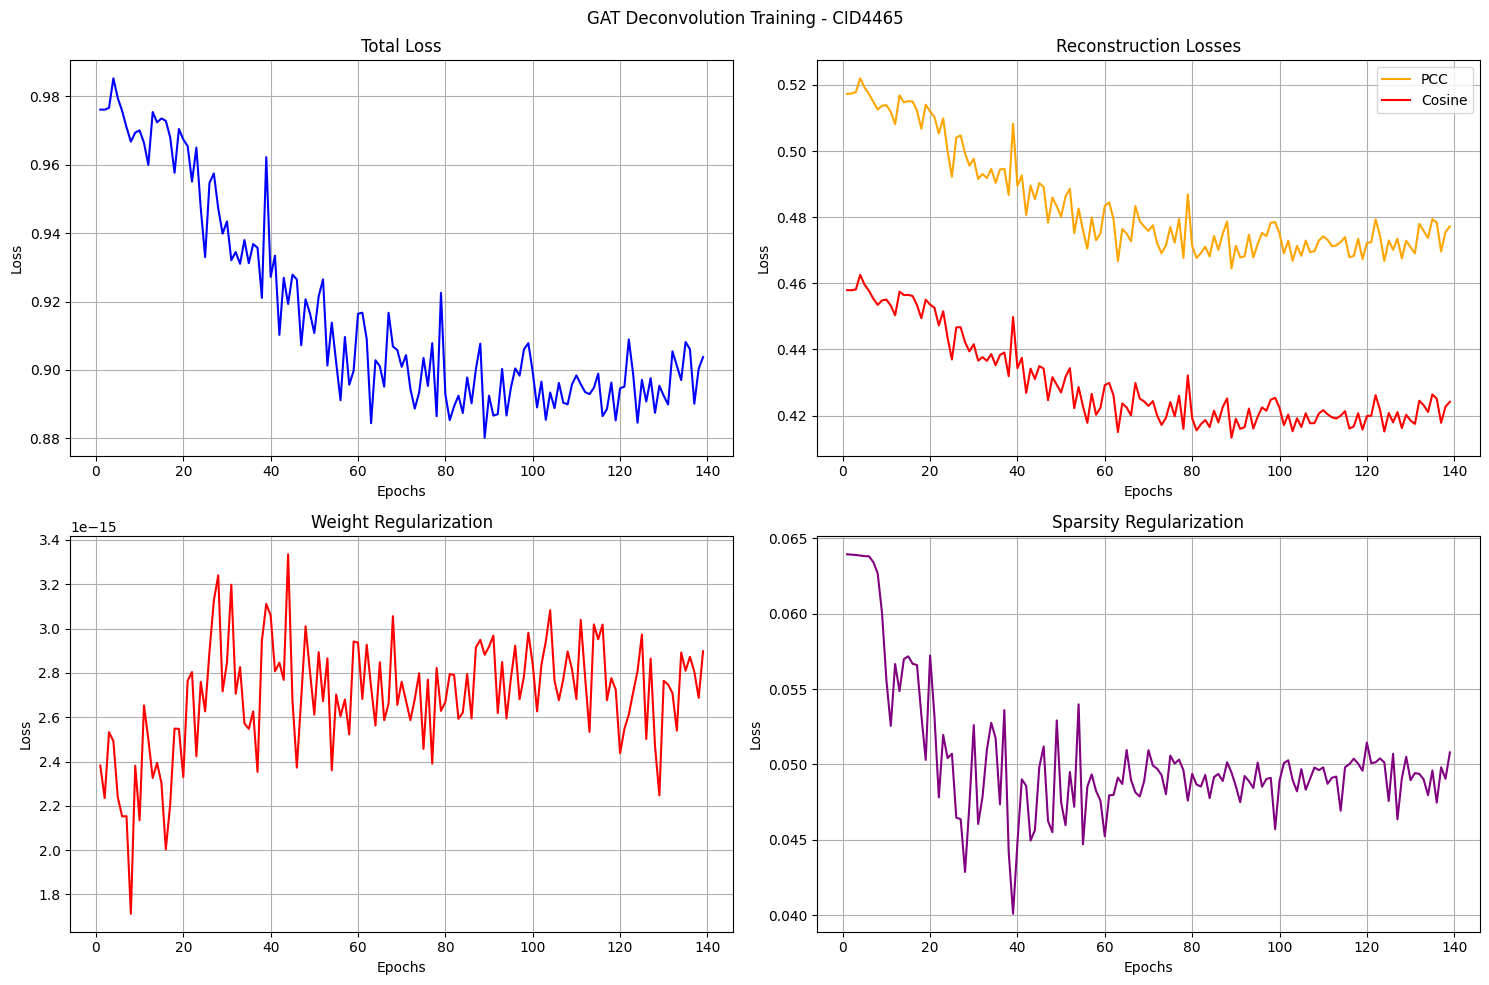

Evaluating model results...
Cells per spot: 10.0
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
Saving deconvolution results...
Generating deconvolution expression matrices...
   Marker gene expression...
   Full gene expression...
   Full gene expression...
   Cell type composition...
   Complete results saved: ./stage2_results/CID4465/2025_1024_1618/CID4465_deconvolution_results.npz
GAT deconvolution training completed!
   Cell type composition...
   Complete results saved: ./stage2_results/CID4465/2025_1024_1618/CID4465_deconvolution_results.npz
GAT deconvolution training completed!


In [2]:
%run stage2.py \
    --st_file "/home/maweicheng/ST_Graduation_Project/database/Wu/CID4465/CID4465_ST.h5ad" \
    --stage1_model_path "./stage1_results/final_vae.pth" \
    --output_dir "./stage2_results/CID4465/2025_1024_1618" \
    --gat_hidden_dim 256 \
    --gat_layers 6 \
    --lr 1e-4 \
    --loss_lambda_pearson 1.0 \
    --loss_lambda_cosine 1.0 \
    --loss_lambda_align 1.0 \
    --loss_lambda_reg 0.5 \
    --loss_lambda_sparse 0.01 \
    --k_spatial 10 \
    --k_celltype 10 \
    --batch_size 128 \
    --n_epochs 500